# 🩺 Diabetes Risk Prediction Project

This project leverages **ensemble learning techniques** to predict the likelihood of diabetes from patient data. The solution has been designed with real-world applications in mind, integrating robust data preprocessing, model evaluation, and hyperparameter tuning to achieve a reliable screening tool for early diabetes detection.

**Modules:**
- **data_preprocessing.py:** Loads and cleans the raw data, including handling missing values and splitting the data into training and test sets.
- **model_training.py:** Defines and evaluates a suite of base classifiers, and trains a soft voting ensemble to improve prediction performance.
- **evaluation.py:** Generates comprehensive evaluation metrics such as classification reports, confusion matrices, ROC and Precision-Recall curves, and visualizes feature importance.
- **tuning.py:** Implements hyperparameter tuning (via GridSearchCV) for Logistic Regression to optimize model performance.
- **inference.py:** Provides utilities for running predictions on new or sample patient data.

This notebook demonstrates the complete workflow—from data ingestion to model evaluation—and includes detailed markdown explanations that document the analytical process and rationale behind each step.


### 📥 Import Libraries

In [3]:
import sys
import os

# Add the src directory to the path so that custom modules are found
sys.path.append(os.path.join(os.getcwd(), "../src"))

# Import necessary libraries and custom modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_preprocessing import load_data, clean_data, split_data
from model_training import define_models, train_voting_classifier, evaluate_model_cv
from evaluation import (
    print_classification_report, 
    plot_conf_matrix, 
    plot_roc_curve, 
    plot_precision_recall_curve, 
    plot_feature_importance
)
from tuning import tune_logistic_regression
from inference import predict_sample

import joblib

## 1. Load & Inspect the Data

Load the Pima Indians Diabetes dataset and rename the columns to make them easier to understand.

In [5]:
# Load the Dataset
data_filepath = "../data/raw/pima-indians-diabetes.csv"
df = load_data(data_filepath)

# Display basic information about the dataset
df.info()
df.describe()
df['Outcome'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Outcome
0    500
1    268
Name: count, dtype: int64

## 2. Clean the Data

Replace implausible zero values in columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI with NaN.   
Apply median imputation to fill these missing values.   .

In [7]:
# Replace zeroes with NaN for selected columns
df = clean_data(df)

# Verify imputation
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3. Split the data
Separate the dataset into the feature matrix (`X`) and the target vector (`y`).  
Here, `Outcome` is the binary variable indicating diabetes status (1 = diabetic, 0 = non-diabetic). 

Split the dataset into training and test sets. **Stratified sampling** is used to maintain the same ratio of diabetic to non-diabetic cases in both sets. This helps ensure that our models learn and are evaluated on data that reflects the overall population.   

Set `random_state=42` for reproducibility.  .


In [9]:
# Split the data into train and test sets with Stratification

X_train, X_test, y_train, y_test = split_data(df)

## 4. Define and Evaluate Base Models

Initialize a suite of models:
- Logistic Regression
- Random Forest
- SVM
- Decision Tree
- Extra Trees

Each model is set with a balanced class weight to handle the fact that there are more non-diabetic cases than diabetic cases.

In [11]:
# Define multiple models with class_weight balanced
models = define_models()

.
For each model, create a pipeline that applies `StandardScaler` followed by the classifier.  
Evaluate performance using **stratified 5-fold cross-validation** and report the mean F1-score (with standard deviation)

In [13]:
# Evaluate each model using stratified 5-fold cross-validation and print the F1 scores.
print("Cross-Validated F1 Scores:")
for model_name, model in models.items():
    mean_score, std_score = evaluate_model_cv(model, X_train, y_train)
    print(f"{model_name:<15} | F1 Score (CV): {mean_score:.4f} ± {std_score:.4f}")

Cross-Validated F1 Scores:
logreg          | F1 Score (CV): 0.6660 ± 0.0336
random_forest   | F1 Score (CV): 0.6352 ± 0.0439
svm             | F1 Score (CV): 0.6633 ± 0.0603
decision_tree   | F1 Score (CV): 0.5646 ± 0.0495
extra_trees     | F1 Score (CV): 0.6615 ± 0.0648


📌**NOTE:** Higher scores indicate better balance between precision and recall. **Logistic Regression, SVM, and Extra Trees** yield the strongest results.

## 5. Train Voting Classifier (Ensemble Model)

Construct a soft voting classifier that aggregates the predictions from all the base models. Soft voting averages the predicted probabilities, which can lead to better performance on imbalanced datasets.  

In [16]:
# Train the soft voting ensemble classifier using the base models.
voting_model = train_voting_classifier(X_train, y_train, models)

## 6. Evaluate the Ensemble on the Test Set
Evaluate the ensemble classifier on the test set to see how well it performs using metrics such as precision, recall, and F1-score.
### 6.1 Classification Report and Confusion Matrix


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       150
           1       0.70      0.62      0.66        81

    accuracy                           0.77       231
   macro avg       0.76      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231

Confusion Matrix:
 [[129  21]
 [ 31  50]]


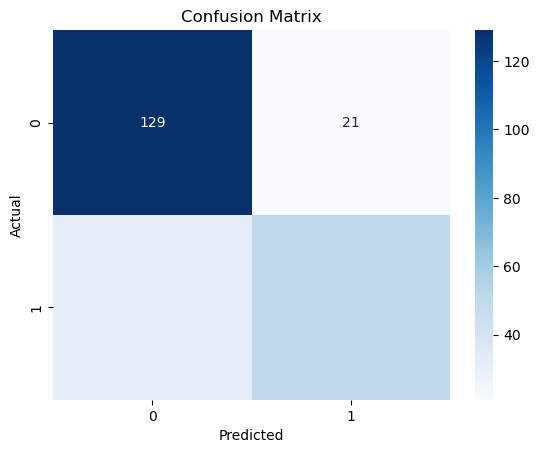

In [18]:
# Evaluate the ensemble model on the test set
y_pred = print_classification_report(voting_model, X_test, y_test)
plot_conf_matrix(y_test, y_pred)

📌**NOTE:** The positive class (diabetic) shows a precision around 0.70, recall around 0.62, and an F1-score around 0.66.

### 6.2 ROC Curve and Precision-Recall Curve
Generate the ROC curve to show the trade-off between the true positive rate and the false positive rate. Also, generate the Precision-Recall curve to understand the balance between precision and recall for detecting diabetic cases, which is critical given the class imbalance.

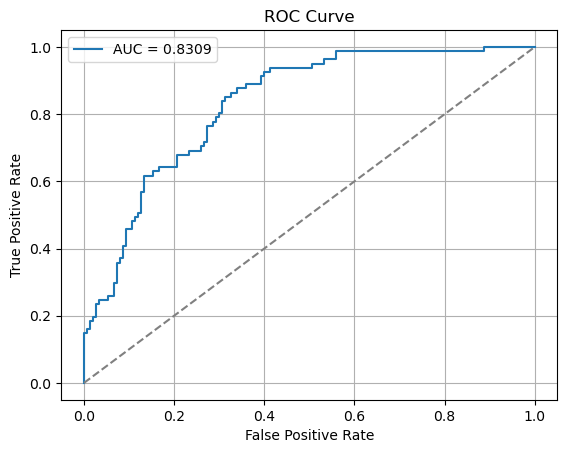

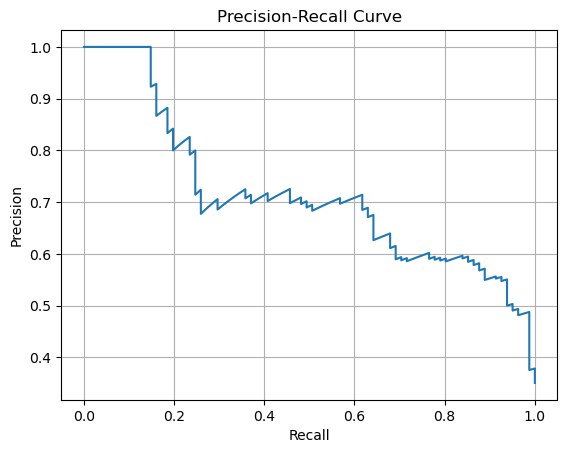

In [21]:
# Get predicted probabilities for ROC and Precision-Recall curves
y_proba = voting_model.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_proba)
plot_precision_recall_curve(y_test, y_proba)

📌**NOTE:**
- **AUC** value of **0.83** indicates that the classifier performs well in distinguishing diabetic from non-diabetic cases.
- **Precision-Recall curve** shows a reasonable balance between precision and recall across different thresholds. This visualization supports understanding of the classifier's behavior in clinical decision-making.

## 7. Display Feature Importance

Examine feature importance using the random Forest model to understand which variables most strongly impact diabetes predictions.  

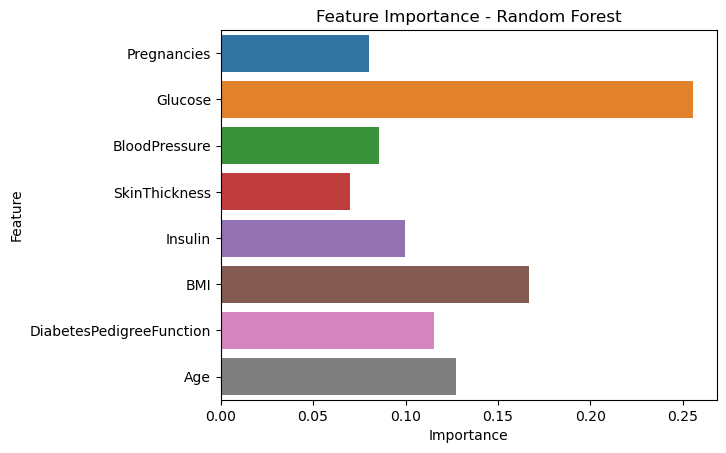

In [25]:
# Plot feature importance using the Random Forest component from the ensemble.
plot_feature_importance(voting_model, X_train.columns)

📌**NOTE:** The bar chart indicates that **Glucose is the most influential feature**, followed by BMI, and Age. This ranking aligns with clinical expectations:

- **Glucose:** A high glucose level is a primary indicator of diabetes risk.
- **BMI:** Excess body weight strongly correlates with insulin resistance and metabolic issues.
- **Age:** Older age can increase diabetes susceptibility, though early-onset is also possible. 

This hierarchy supports the domain knowledge that elevated glucose and body mass are key predictors for type 2 diabetes.

## 8. Simulate Inference on a Sample Patient

Perform a prediction on a single test instance to see how the model works in practice.   
Print the patient data along with the prediction to provide context for the output.  

In [41]:
# Simulate making a prediction for a single patient sample from the test set.
sample = X_test.iloc[0:1]
sample_prediction = predict_sample(voting_model, sample)
print("Prediction for the sample patient:", "Diabetic" if sample_prediction[0] == 1 else "Non-Diabetic")
print("\nSample Patient Data:")
print(sample)

Prediction for the sample patient: Non-Diabetic

Sample Patient Data:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
730            3    130.0           78.0           23.0     79.0  28.4   

     DiabetesPedigreeFunction  Age  
730                     0.323   34  


## 9. Tune Logistic Regression using GridSearchCV

Optimize the regularization parameter `C` for Logistic Regression using GridSearchCV within a pipeline. This step fine-tunes the model to achieve the best possible balance between underfitting and overfitting.

In [45]:
# Grid Search for Logistic Regression hyperparameter tuning
best_estimator, best_params, best_score = tune_logistic_regression(X_train, y_train)
print("Best Parameters:", best_params)
print("Best F1 Score:", best_score)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'logisticregression__C': 1}
Best F1 Score: 0.6775146894123913


📌**NOTE:** The best parameter found is `C=1`, which yield a cross-validated F1-score of approximately 0.6775. This result indicates:

- **Regularization Strength:** A `C` value of 1 balances regularization and model complexity effectively for this dataset.
- **Cross-Validated F1:** ~0.68 suggests that the tuned logistic regression model handles the imbalanced classes with reasonable precision-recall trade-off.

Overall, the **0.6775** F1 score aligns closely with the ensemble’s performance range, reinforcing that logistic regression — when properly tuned — remains a competitive baseline for this medical classification problem.

In [47]:
# Save the tuned logistic regression model
joblib.dump(best_estimator, "../models/logreg_best.pkl")

['../models/logreg_best.pkl']

## 📌 Summary of Insights

### 🎯 Objective:
Predict the likelihood of diabetes using patient data, with a focus on ensemble methods and hyperparameter tuning for optimal performance.

---

### ✅ Key Results:
1. **Cross-Validation (Training Data):**

- Using 5-fold stratified cross-validation on the training set, the F1-scores (mean ± std) are:

| Model           | Mean F1 (CV)    |
|-----------------|-----------------|
| Logistic Reg    | 0.6660 ± 0.0336 |
| Random Forest   | 0.6352 ± 0.0439 |
| SVM             | 0.6633 ± 0.0603 |
| Decision Tree   | 0.5646 ± 0.0495 |
| Extra Trees     | 0.6615 ± 0.0648 |


- **Logistic Regression** and **SVM** yield the highest cross-validated F1-scores, around **0.66–0.67.**

2. **Ensemble Performance on Test Data:**
   - **Precision (Class 1):** ~0.70
   - **Recall (Class 1):** ~0.62
   - **F1-Score (Class 1):** ~0.66
   - **Accuracy:** ~0.77
   - **AUC (ROC):** ~0.83
   
3. **Confusion Matrix:**
   - True Negatives: 129
   - False Positives: 21
   - False Negatives: 31
   - True Positives: 50

While **21 false positives** remain, more concerning are the **31 false negatives** — undetected diabetic cases. In a healthcare context, missing diabetic cases (FN) can pose higher risk, suggesting further recall improvement is valuable.

4. **Feature Importance:**

- Random Forest feature importance reveals **Glucose** as the most critical predictor, followed by **BMI, Age, and BloodPressure.** This aligns with clinical understanding of diabetes risk factors.

5. **Hyperparameter Tuning:**

- A GridSearchCV identified `C=1` as the best regularization parameter for Logistic Regression, yielding an F1-score of **0.6775** in cross-validation. This indicates that moderate regularization is optimal for this dataset.


---

### 🔍 Business Insight:
- **Screening Tool**: The ensemble model can be used to flag high-risk individuals for further clinical tests (e.g., HbA1c), especially when resources are limited.
- **Preventive Value**: Feature importance aligns with medical knowledge, enhancing trust from healthcare professionals.

---

### 🚀 Next Steps:
1. **Increase Recall:** Missing diabetic cases is risky. Consider:
- Adjusting decision thresholds to favor recall.
- Using SMOTE or cost-sensitive learning to address class imbalance.

2. **Advanced Interpretability:** Techniques like SHAP or LIME can clarify individual predictions, building stakeholder confidence.

---